### [1]

         feature_0    feature_1    feature_2    feature_3    feature_4  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean      3.632037     3.637768     3.646830     3.649878     3.716338   
std       4.704402     4.707993     4.721284     4.663691     4.652731   
min      -4.459959    -4.490560    -4.981672    -4.550984    -4.862271   
25%      -0.078919    -0.073683    -0.089175     0.042183     0.125684   
50%       1.607282     1.512604     1.555909     1.442576     1.665105   
75%       9.340937     9.314537     9.372775     9.175368     9.298946   
max      13.019653    12.933403    12.955533    13.002652    13.602415   

         feature_5    feature_6    feature_7    feature_8    feature_9  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean      3.698533     3.676957     3.633943     3.680890     3.655957   
std       4.681893     4.723364     4.707999     4.699249     4.657697   
min      -4.994256    -4.961850    -4

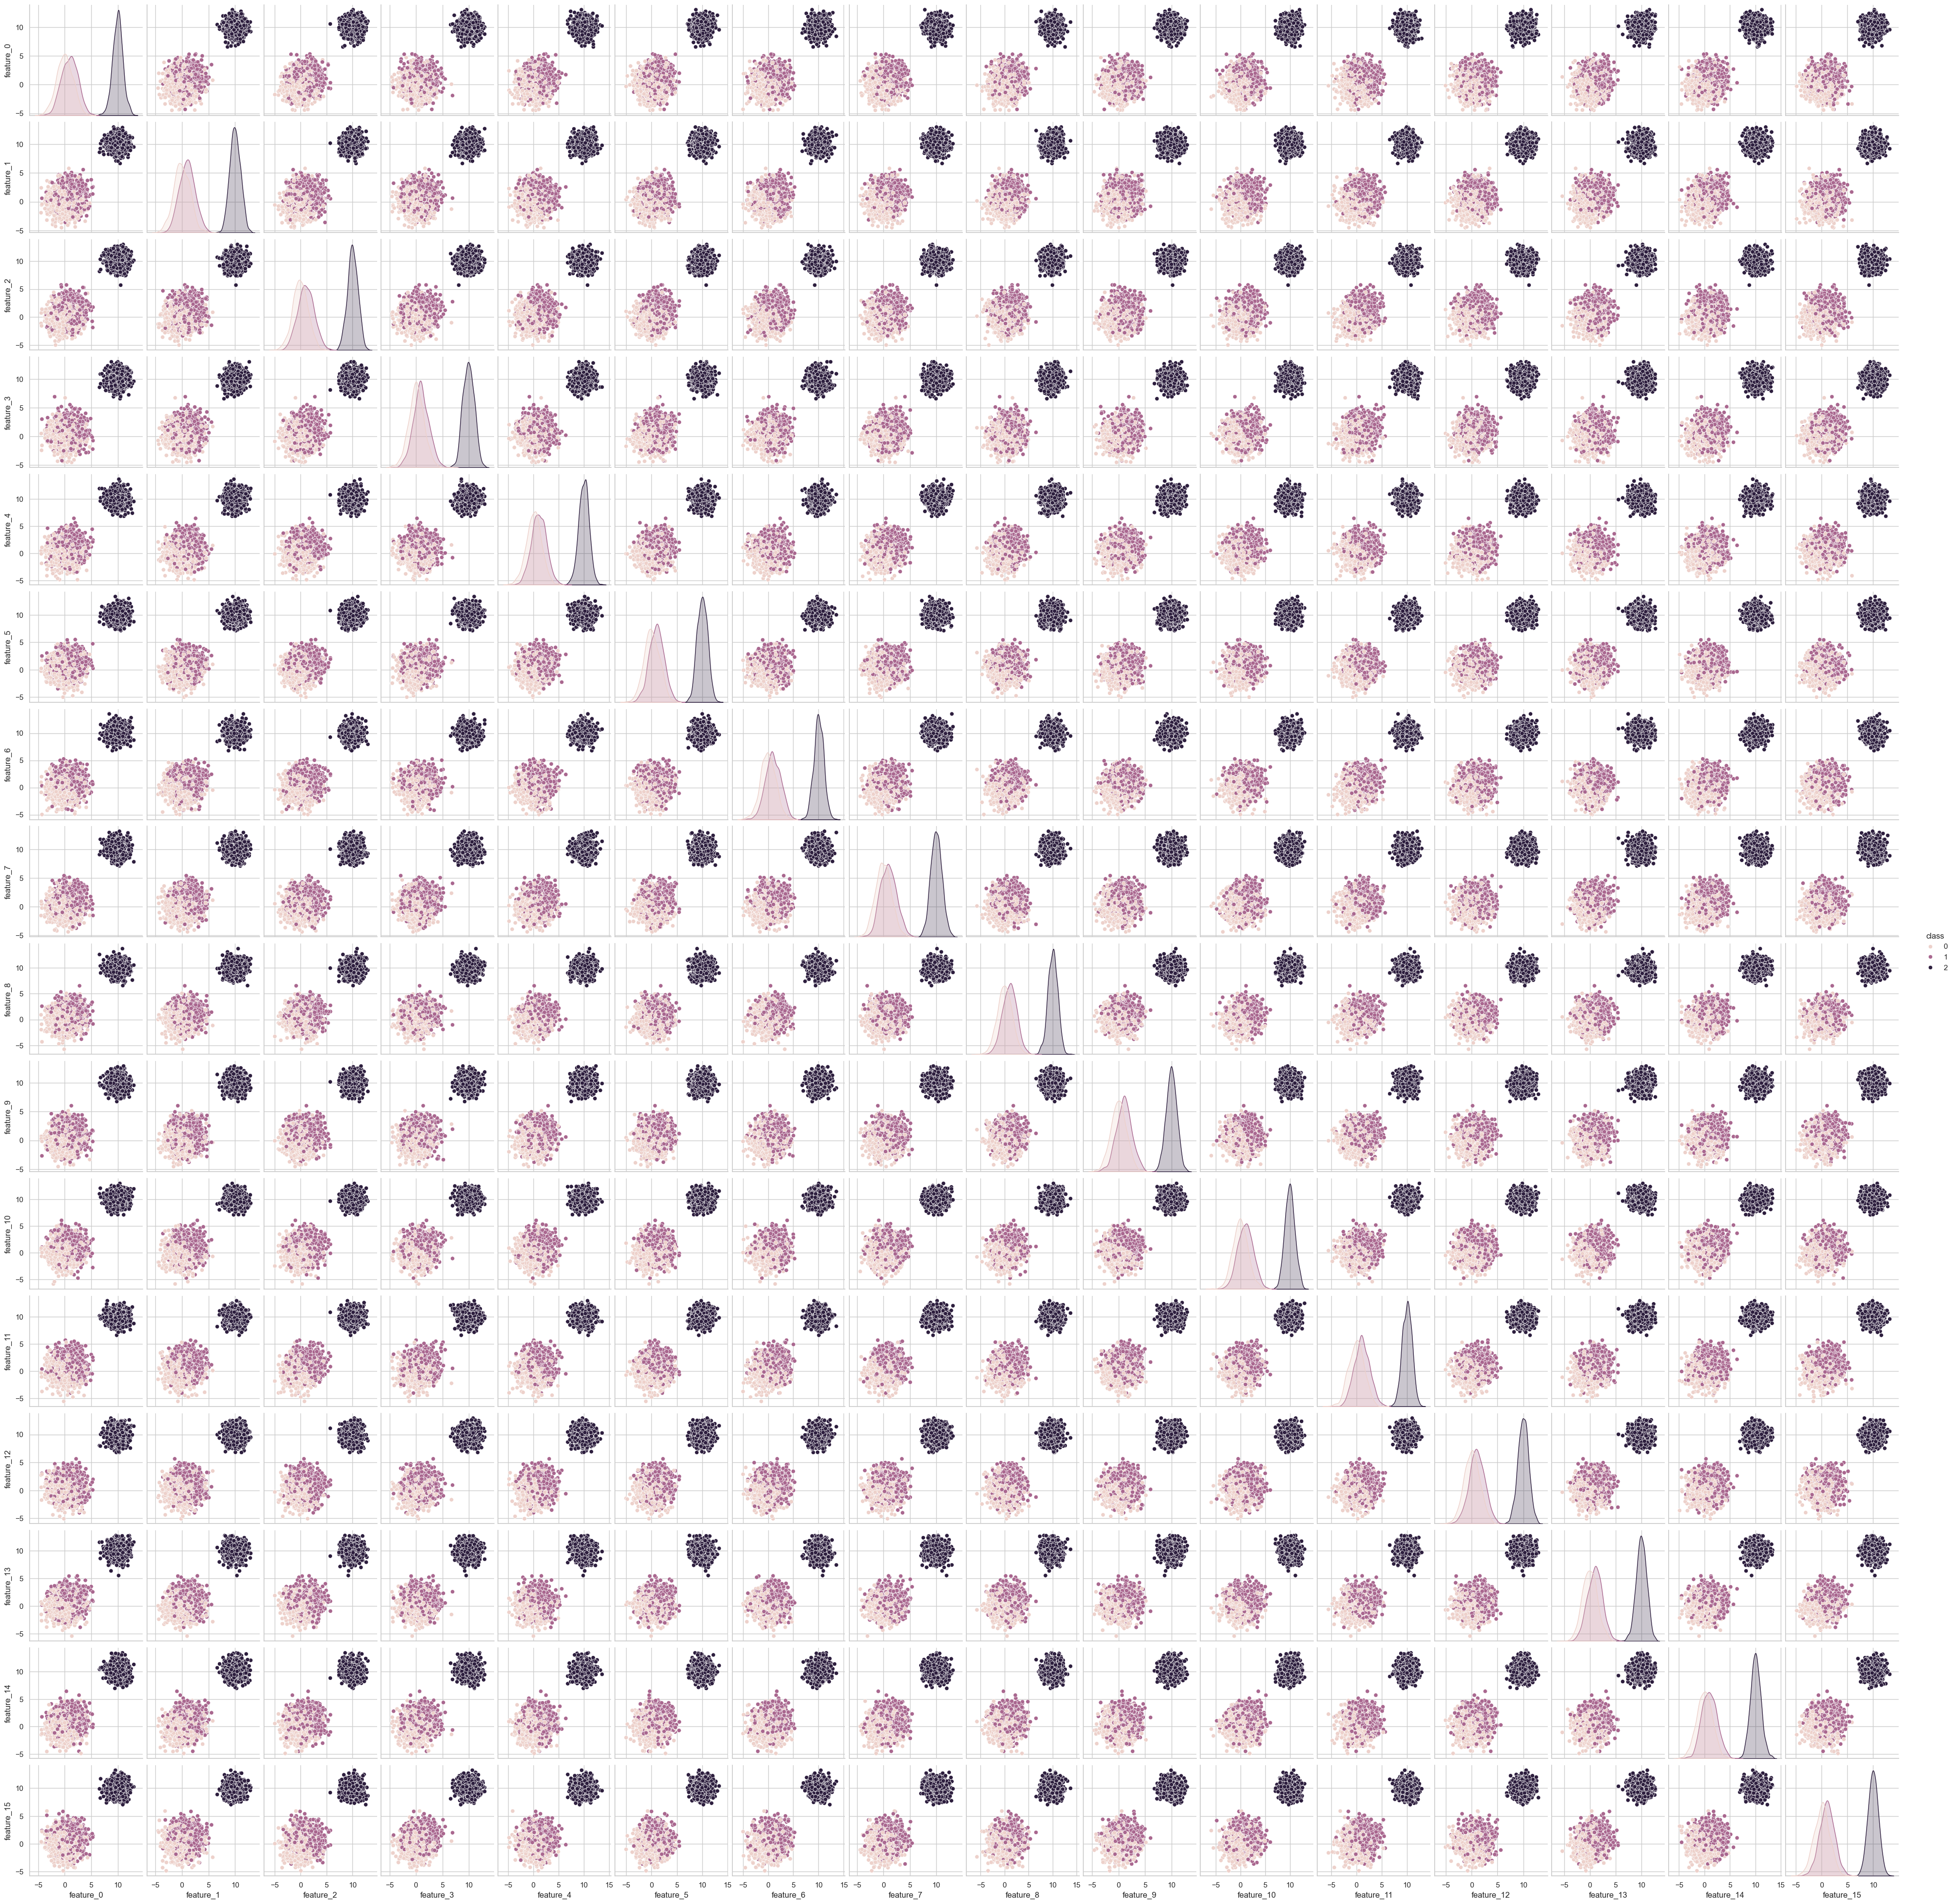

In [ ]:
import pandas as pd
from sklearn.datasets import make_blobs
import seaborn as sns
import matplotlib.pyplot as plt

# Generate dataset
centers = [[0]*16, [1]*16, [10]*16]  # Close centers for class 0 and 1, far for 2
cluster_std = [1.5, 1.5, 1.0]  # Higher std for overlap between 0 and 1
X, y = make_blobs(n_samples=[1000, 1000, 1000], n_features=16, centers=centers, cluster_std=cluster_std, random_state=42)

df1 = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(16)])
df1['class'] = y

print(df1.describe())

corr = df1.corr()
print(corr)

sns.pairplot(df1, hue='class', diag_kind='kde')
plt.show()

### [2]

In [ ]:
import pandas as pd

# Identify class with overlap (class 0 or 1, choosing class 0)
class_to_repeat = 0

def create_repeated_dataset(df, n_repeats, class_label):
    class_data = df[df['class'] == class_label]
    repeated_class = pd.concat([class_data] * n_repeats, ignore_index=True)
    other_classes = df[df['class'] != class_label]
    return pd.concat([repeated_class, other_classes], ignore_index=True)

df2 = create_repeated_dataset(df1, 2, class_to_repeat)
df5 = create_repeated_dataset(df1, 5, class_to_repeat)
df10 = create_repeated_dataset(df1, 10, class_to_repeat)
df20 = create_repeated_dataset(df1, 20, class_to_repeat)
df50 = create_repeated_dataset(df1, 50, class_to_repeat)
df100 = create_repeated_dataset(df1, 100, class_to_repeat)
df1000 = create_repeated_dataset(df1, 1000, class_to_repeat)
df10k = create_repeated_dataset(df1, 10000, class_to_repeat)